# Project - Car Price Predicition

## 1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')



## 2. LOAD DATASET

In [4]:
# Load Dataset

df = pd.read_csv("car data.csv")


## 3. DATASET FIRST VIEW

In [5]:
# First 5 Rows

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 4. DATASET INFORMATION

In [6]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


## 5. DATASET SHAPE

In [7]:
# Rows and Columns

print("Dataset Shape:", df.shape)

Dataset Shape: (301, 9)


## 6. CHECK MISSING VALUES

In [8]:
# Missing Values

df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## 7. STATISTICAL SUMMARY

In [9]:
# Statistical Summary

df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 8. CHECK DUPLICATE VALUES

In [10]:
# Duplicate Values

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


## 9. DATA PREPROCESSING

#### Convert Car Age Feature

In [11]:
# Creating Car Age Feature

df['Car_Age'] = 2026 - df['Year']

# Drop Year Column
df.drop('Year', axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


## 10. LABEL ENCODING

In [12]:
# Convert Categorical Columns into Numerical

le = LabelEncoder()

categorical_columns = ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,90,3.35,5.59,27000,2,0,1,0,12
1,93,4.75,9.54,43000,1,0,1,0,13
2,68,7.25,9.85,6900,2,0,1,0,9
3,96,2.85,4.15,5200,2,0,1,0,15
4,92,4.60,6.87,42450,1,0,1,0,12


## 11. FEATURE AND TARGET SELECTION

In [13]:
# Features (X) and Target (y)

X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (301, 8)
Target Shape: (301,)


## 12. FEATURE SCALING

In [14]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 13. TRAIN TEST SPLIT

In [15]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (240, 8)
Testing Data Shape: (61, 8)


## 14. DATA VISUALIZATION

#### Correlation Heatmap

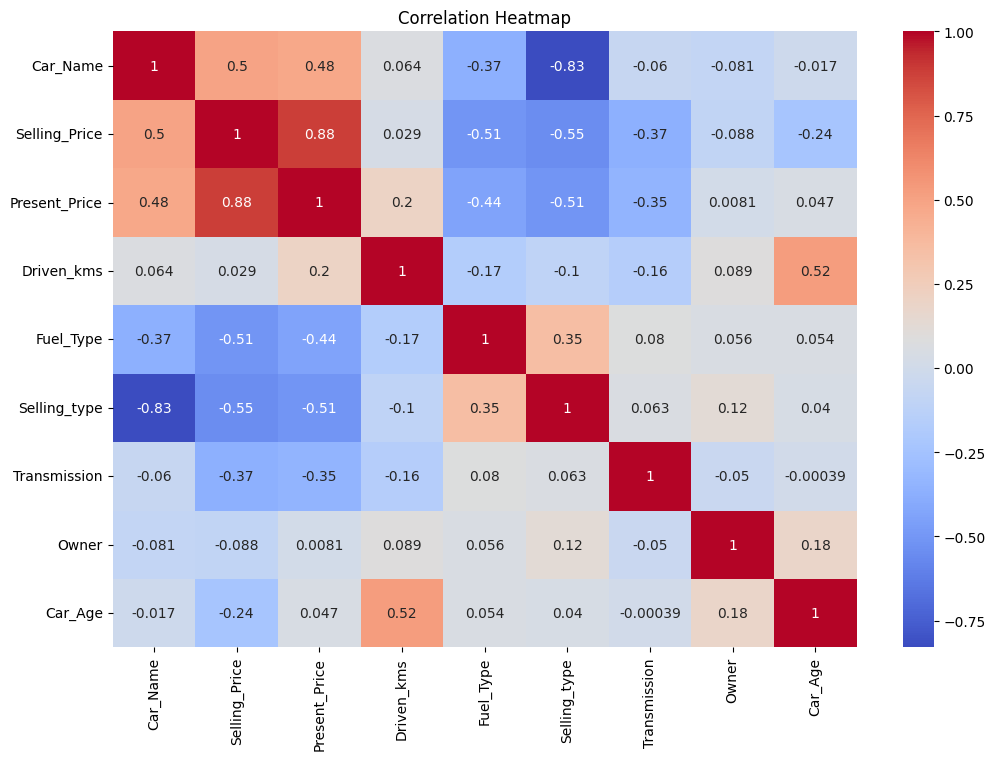

In [16]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

#### Car Price Distribution

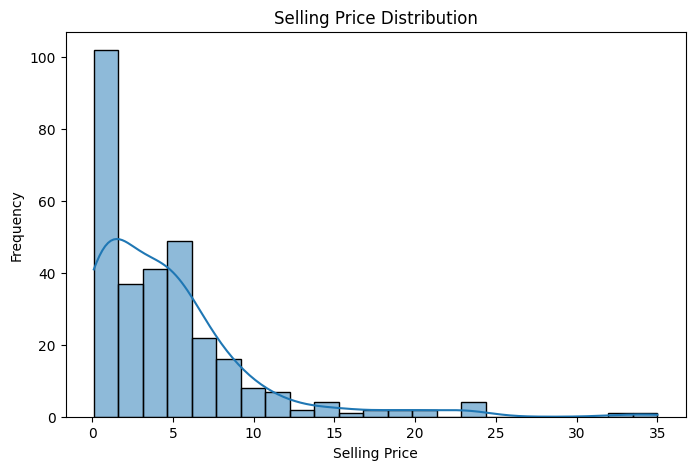

In [17]:
# Selling Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

#### Fuel Type Countplot

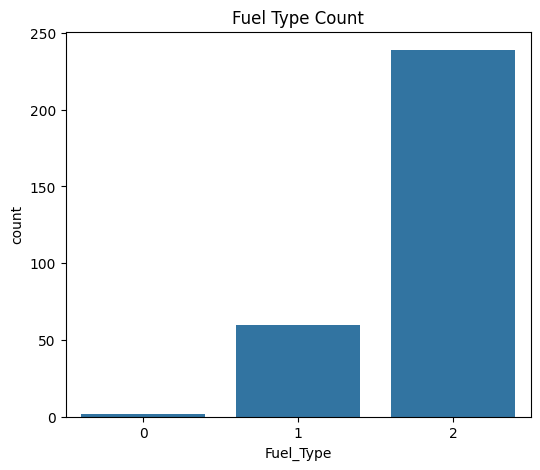

In [18]:
# Fuel Type Countplot

plt.figure(figsize=(6,5))

sns.countplot(x='Fuel_Type', data=df)

plt.title("Fuel Type Count")

plt.show()

#### Car Age vs Selling Price

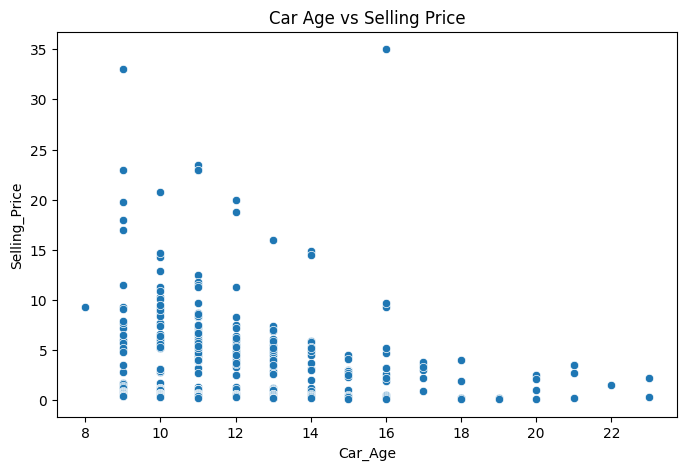

In [19]:
# Car Age vs Selling Price

plt.figure(figsize=(8,5))

sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)

plt.title("Car Age vs Selling Price")

plt.show()

## 15. MACHINE LEARNING MODELS

#### MODEL 1 : LINEAR REGRESSION

In [20]:
# Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

#### MODEL 2 : DECISION TREE REGRESSOR

In [21]:
# Decision Tree Regressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

#### MODEL 3 : RANDOM FOREST REGRESSOR

In [22]:
# Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

#### MODEL 4 : SUPPORT VECTOR MACHINE (SVR)

In [23]:
# Support Vector Regressor

svr_model = SVR()

svr_model.fit(X_train, y_train)

# Prediction
svr_pred = svr_model.predict(X_test)

#### MODEL 5 : XGBOOST REGRESSOR

In [24]:
# XGBoost Regressor

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

# Prediction
xgb_pred = xgb_model.predict(X_test)

## 16. MODEL EVALUATION FUNCTION

In [25]:
# Evaluation Function

def evaluate_model(y_test, predictions, model_name):

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    print(f"\n{model_name} Performance")
    print("-" * 40)

    print("MAE  :", mae)
    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("R2 Score :", r2)

## 17. EVALUATE ALL MODELS

In [26]:
# Linear Regression
evaluate_model(y_test, lr_pred, "Linear Regression")

# Decision Tree
evaluate_model(y_test, dt_pred, "Decision Tree")

# Random Forest
evaluate_model(y_test, rf_pred, "Random Forest")

# SVR
evaluate_model(y_test, svr_pred, "Support Vector Regressor")

# XGBoost
evaluate_model(y_test, xgb_pred, "XGBoost Regressor")


Linear Regression Performance
----------------------------------------
MAE  : 1.2147329896559536
MSE  : 3.5370204237558136
RMSE : 1.8806967920842035
R2 Score : 0.8464540623816023

Decision Tree Performance
----------------------------------------
MAE  : 0.6698360655737704
MSE  : 1.13087868852459
RMSE : 1.0634278012750042
R2 Score : 0.9509073152657148

Random Forest Performance
----------------------------------------
MAE  : 0.5804016393442625
MSE  : 0.7559900070491803
RMSE : 0.8694768582597125
R2 Score : 0.9671816442780825

Support Vector Regressor Performance
----------------------------------------
MAE  : 0.9946948470507921
MSE  : 4.9582906043581145
RMSE : 2.226721941410313
R2 Score : 0.7847551643419013

XGBoost Regressor Performance
----------------------------------------
MAE  : 0.5749825260287426
MSE  : 0.9836582465169885
RMSE : 0.9917954660699899
R2 Score : 0.9572983161920393


## 18. COMPARE MODELS

In [27]:
# Model Comparison

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVR', 'XGBoost']

r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, svr_pred),
    r2_score(y_test, xgb_pred)
]

comparison_df = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores
})

comparison_df

,Model,R2 Score
0,Linear Regression,0.846454
1,Decision Tree,0.950907
2,Random Forest,0.967182
3,SVR,0.784755
4,XGBoost,0.957298


## 19. VISUALIZE MODEL PERFORMANCE

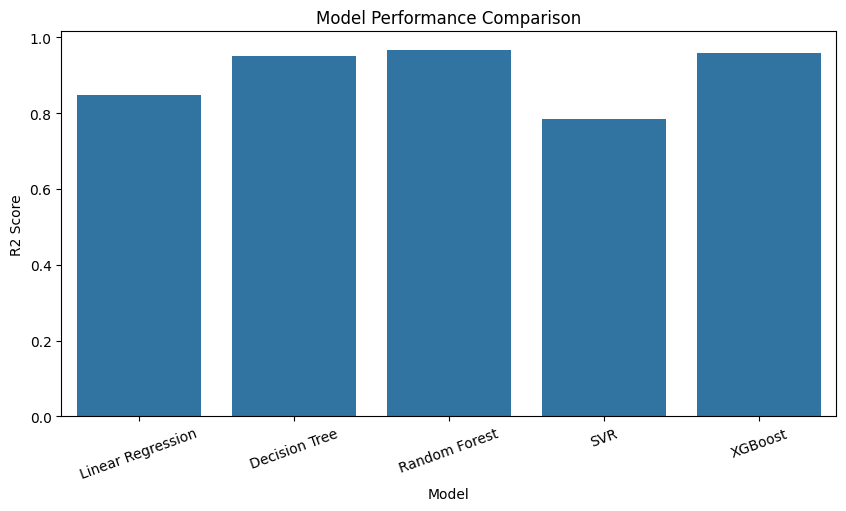

In [28]:
# Model Performance Visualization

plt.figure(figsize=(10,5))

sns.barplot(x='Model', y='R2 Score', data=comparison_df)

plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.show()

## 20. BEST MODEL

In [29]:
# Best Model

best_model = comparison_df.sort_values(by='R2 Score', ascending=False)

best_model.head(1)

,Model,R2 Score
2,Random Forest,0.967182


## 21. FEATURE IMPORTANCE (RANDOM FOREST)

In [30]:
# Feature Importance

importance = rf_model.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

feature_df

,Feature,Importance
1,Present_Price,0.869197
7,Car_Age,0.053791
2,Driven_kms,0.036299
0,Car_Name,0.029633
5,Transmission,0.007477
4,Selling_type,0.002178
3,Fuel_Type,0.001365
6,Owner,0.000061


## 22. FEATURE IMPORTANCE VISUALIZATION

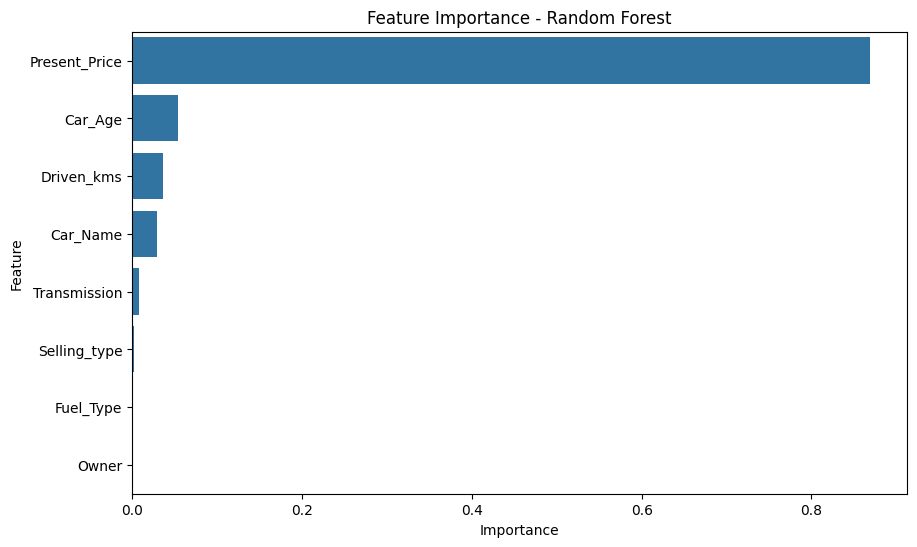

In [31]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance - Random Forest")

plt.show()

## 23. CONCLUSION

In [32]:
print("""
Conclusion:

1. Successfully performed data preprocessing.
2. Applied feature engineering using Car Age.
3. Trained multiple regression models.
4. Evaluated models using MAE, MSE, RMSE and R2 Score.
5. Compared model performances visually.
6. Random Forest and XGBoost usually perform best for price prediction tasks.
""")


Conclusion:

1. Successfully performed data preprocessing.
2. Applied feature engineering using Car Age.
3. Trained multiple regression models.
4. Evaluated models using MAE, MSE, RMSE and R2 Score.
5. Compared model performances visually.
6. Random Forest and XGBoost usually perform best for price prediction tasks.

